В данном файле проводится анализ и обработка тестов юридических статей с сайта pravo.ru и обучение модели наивного Байесовского классификатора для классификации текстов по категориям.

# Импорт библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm.auto import tqdm
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

from collections import Counter
from typing import List
import string
import re
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, balanced_accuracy_score, roc_auc_score,
    precision_recall_fscore_support,
)
import joblib
from tqdm import tqdm
from sklearn.pipeline import make_pipeline
sns.set(palette='summer')

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


False

In [ ]:
!pip install natasha

In [ ]:
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    Doc
)

# Загрузка и анализ данных

In [ ]:
df=pd.read_csv('all_articles.csv', on_bad_lines='skip')

In [ ]:
df[df.isna().any(axis=1)] #видим что в процессе парсинга часть данных не запарсилась, удалим пропуски


,category,article_site,title,short_description,article
695,Практика,https://t.me/pravo_pravo/3705,NaN,NaN,NaN
750,Практика,https://t.me/pravo_pravo/3641,NaN,NaN,NaN
1121,Практика,https://t.me/pravo_pravo/3416,NaN,NaN,NaN
1153,Практика,https://t.me/pravo_pravo/3410,NaN,NaN,NaN
1157,Практика,https://pravo.ru/news/255956/,ФАС признала ненадлежащей рекламу кредитки ВТБ,NaN,"ФАС сообщила, что по итогам рассмотрения дела ..."
1162,Практика,https://pravo.ru/news/255946/,Директор ФССП рассказал об успехах национализа...,NaN,Директор Федеральной службы судебных приставов...
1236,Практика,https://t.me/pravo_pravo/3386,NaN,NaN,NaN
1271,Практика,https://t.me/pravo_pravo/3378,NaN,NaN,NaN
1306,Практика,https://t.me/pravo_pravo/3365,NaN,NaN,NaN
1309,Практика,https://t.me/pravo_pravo/3363,NaN,NaN,NaN


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.iloc[0] #посмотрим на пример данных

,0
category,Практика
article_site,https://pravo.ru/story/260331/
title,Тренды в налоговой сфере: как они влияют на би...
short_description,Число налоговых проверок растет. Налоговые орг...
article,С весны ощутимо выросло число проводимых налог...


In [ ]:
df['article']=df['title']+'. '+df['article'] #объединим заголовки с текстами статей

In [ ]:
df['article'][0]

'Тренды в налоговой сфере: как они влияют на бизнес. С весны ощутимо выросло число проводимых налоговых проверок, поэтому компании стали чаще обращаться к юристам, отмечает Игорь Смирнов, старший партнер, руководитель налоговой и финансовой практик Эксперт выделил несколько фокусов налоговой. Так, пристальное внимание ФНС сейчас уделяет взаимодействию бизнеса с индивидуальными предпринимателями и самозанятыми. По поводу последних налоговики регулярно проводят комиссии, вызывая налогоплательщиков и обсуждая с ними переквалификацию отношений из гражданско-правовых в трудовые.Не менее актуальными остаются вопросы дробления бизнеса, продолжает Смирнов. Из-за них налоговые органы предъявляют бизнесу много требований. При этом особое внимание ФНС уделяет «нетипичным» схемам. Например, когда бизнес разделяют так, чтобы каждая компания попадала под критерии малого и среднего предпринимательства и, соответственно, могла применять пониженные тарифы по страховым взносам. Для классических схем дро

Для обучения возьмем тольок текст статей и категорию

In [ ]:
df=df[['category', 'article']]

In [ ]:
df

,category,article
0,Практика,Тренды в налоговой сфере: как они влияют на би...
1,Практика,Амнистия не снизила число компаний с признакам...
2,Практика,Центробанк снизил ключевую ставку до 17%. Сове...
3,Практика,Суд ЕС: активы можно разблокировать для уплаты...
4,Практика,Власти обсуждают повышение НДС до 22%. Правите...
...,...,...
18174,Важнейшие правовые темы в прессе,Важнейшие правовые темы в прессе за 12.02.2018...
18175,Важнейшие правовые темы в прессе,"Темы недели: старт ""процессуальной революции"",..."
18176,Важнейшие правовые темы в прессе,Важнейшие правовые темы в прессе за 07.02.2018...
18177,Важнейшие правовые темы в прессе,Темы недели. Когда он впервые занял эту должно...


Посмотрим на распределние целевой переменной

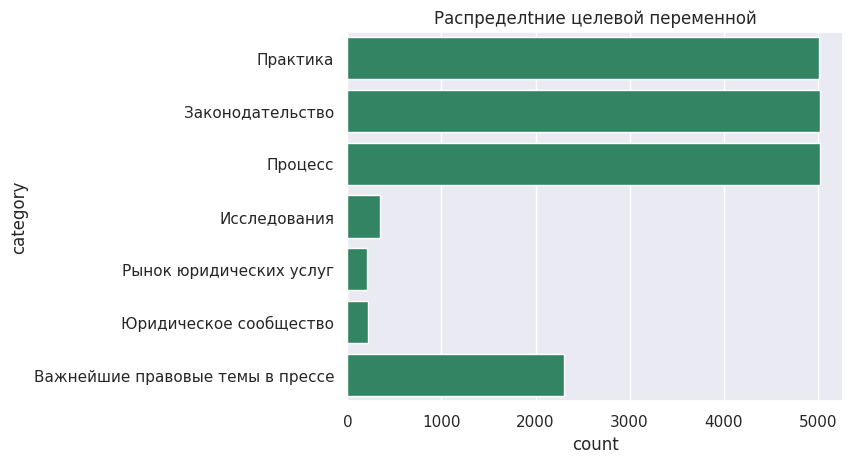

In [ ]:
sns.countplot(df['category'])
plt.title('Распределtние целевой переменной')
plt.show()

Практика, Законодательство и Процесс на одном уровне, очень мало статей тематики Исследования, Рынок юридических услуг и Юридическое сообщество, объедим их вместе с Важнейгими правовцми темами в прессе в категорию "Другое"

In [ ]:
mask=df['category'].isin(['Исследования', 'Рынок юридических услуг', 'Юридическое сообщество', 'Важнейшие правовые темы в прессе'])

In [ ]:
df.loc[mask, 'category'] = 'Другое'

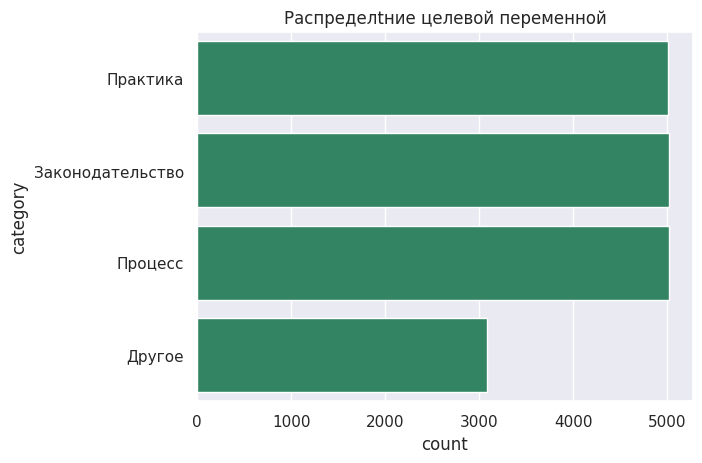

In [ ]:
sns.countplot(df['category'])
plt.title('Распределtние целевой переменной')
plt.show()

Разделим на обучающую, валидационную и тестовую выборки в пропорциях 70:15:15

In [ ]:
train_df, second_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['category'],
    shuffle=True
)

In [ ]:
test_df, val_df = train_test_split(
    second_df,
    test_size=0.5,
    random_state=42,
    stratify=second_df['category'],
    shuffle=True
)

In [ ]:
train_df.to_csv('train_df.csv', index=False, encoding='utf-8-sig')
val_df.to_csv('val_df.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('test_df.csv', index=False, encoding='utf-8-sig')

In [ ]:
train_df

,category,article
16144,Другое,Утренний обзор за 2 августа. С соответствующим...
12286,Процесс,ВС решит вопрос о выборе управляющего «Открыти...
16832,Другое,"Обзор СМИ за 1 июля. , сообщает «Коммерсант». ..."
17129,Другое,Обзор СМИ за 30 июля. . Об этом пишет «Коммерс...
241,Практика,Минпромторг предложил ввести промышленный сбор...
...,...,...
8456,Законодательство,В ГД внесли законопроект об электронном кадров...
17467,Другое,«Субсидиарка» за вывод активов и спор о сроках...
17828,Другое,Важнейшие правовые темы в прессе – обзор СМИ (...
5072,Законодательство,Путин ввел спецпорядок приема документов о мар...


In [ ]:
val_df

,category,article
11092,Процесс,Суд сохранил арест имущества переданного госуд...
2434,Практика,ВС изучил дело о списании неустойки. Научно-пр...
2291,Практика,ВС призвал сравнивать оказываемые услуги в спо...
7707,Законодательство,Кабмин разрешил не платить патентообладателям ...
15544,Другое,Автоматизируй это! Кейсы юридических департаме...
...,...,...
7902,Законодательство,Опубликован новый проект поправок об имуществе...
16256,Другое,ВС оценит полномочия жилинспекции по проверке ...
7748,Законодательство,Путин запретил российским резидентам выводить ...
2083,Практика,"ВС объяснил, как штрафовать предпринимателей и..."


In [ ]:
test_df

,category,article
12450,Процесс,UPD: Против Моргенштерна возбудили дело из-за ...
600,Практика,ВС установит критерии субсидиарки после ликвид...
10024,Законодательство,Госдума одобрила штрафы за неисполнение требов...
9872,Законодательство,Многодетным отцам могут разрешить выходить на ...
13121,Процесс,Генпрокуратура направила в суд дело о хищении ...
...,...,...
9791,Законодательство,Комитет Госдумы одобрил пожизненное сенаторств...
11260,Процесс,ЦБ проверит соблюдение запрета на «рекламные с...
6453,Законодательство,ФНС ограничат в дополнительных проверках на пе...
11803,Процесс,Экс-чиновника осудили за мошенничество с контр...


In [ ]:
train_df

,category,article
16144,Другое,Утренний обзор за 2 августа. С соответствующим...
12286,Процесс,ВС решит вопрос о выборе управляющего «Открыти...
16832,Другое,"Обзор СМИ за 1 июля. , сообщает «Коммерсант». ..."
17129,Другое,Обзор СМИ за 30 июля. . Об этом пишет «Коммерс...
241,Практика,Минпромторг предложил ввести промышленный сбор...
...,...,...
8456,Законодательство,В ГД внесли законопроект об электронном кадров...
17467,Другое,«Субсидиарка» за вывод активов и спор о сроках...
17828,Другое,Важнейшие правовые темы в прессе – обзор СМИ (...
5072,Законодательство,Путин ввел спецпорядок приема документов о мар...


Напишем функцию для обработки текста и лемматизации данных:
1) приводим к нижнему регистру;
2) удаляем всю пунктуацию;
3) переводим двойные пробелы в одиночные;
4) удаляем лишние пробелы в начале и в конце;
5)преобразуем текст типа "ст.№" и "п.№";
6) разбиваем на токены - отдельные слова, и применяем демматизацию.


In [ ]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

def clean_russian_text(text):
    text = text.lower()

    russian_punctuation = '«»—№'
    all_punctuation = string.punctuation + russian_punctuation

    translator = str.maketrans('', '', all_punctuation)
    text = text.translate(translator)

    text = re.sub(r'\s+', ' ', text)

    text = text.strip()

    text = re.sub(r'\bст\.?\s*(\d+)', r'статья_\1', text)
    text = re.sub(r'\bп\.?\s*(\d+)', r'пункт_\1', text)
    text = re.sub(r'№\s*(\d+)', r'номер_\1', text)

    text = re.sub(r'\s[а-яё]\s', ' ', text)

    doc = Doc(text)

    doc.segment(segmenter)

    doc.tag_morph(morph_tagger)

    lemmas = []
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
        lemmas.append(token.lemma)

    return ' '.join(lemmas)

for i in tqdm(train_df.index):
    processed_text = clean_russian_text(train_df['article'][i])
    train_df.loc[i, 'article'] = processed_text


100%|██████████| 12692/12692 [15:19<00:00, 13.80it/s]


In [ ]:
train_df

,category,article
16144,Другое,утренний обзор за 2 август соответствующий иск...
12286,Процесс,вс решить вопрос выбор управлять открытие холд...
16832,Другое,обзор сми за 1 июль сообщать коммерсант черный...
17129,Другое,обзор сми за 30 июль о это писать коммерсант с...
241,Практика,минпромторг предложить ввести промышленный сбо...
...,...,...
8456,Законодательство,в гд внести законопроект о электронный кадровы...
17467,Другое,субсидиарк за вывод актив спора срок новый дел...
17828,Другое,важный правовой тема пресса – обзор сми 104 ве...
5072,Законодательство,путин ввести спецпорядок прием документ маркир...


Также делаем счетчик для подсчета сколько раз каждое слово встречается во всех текстах

In [ ]:
words = Counter()
for i in tqdm(train_df.index):
  for word in df['article'][i].split():
    words[word] += 1

100%|██████████| 12692/12692 [00:02<00:00, 4271.25it/s]


In [ ]:
dict(sorted(words.items(), key=lambda item: item[1], reverse=True)) #посмотрим на самые популярные слова, видим что в основном это слова не несущие в себе смысла, удалим их

{'в': 151730,
 'и': 107753,
 'на': 67469,
 'не': 45025,
 'с': 44377,
 'по': 43633,
 'что': 42793,
 'о': 30339,
 'В': 25746,
 'к': 23172,
 'для': 20774,
 'за': 20390,
 '—': 19240,
 'от': 17570,
 'а': 17219,
 'руб.': 16130,
 'из': 15512,
 'его': 14044,
 '–': 12836,
 'суд': 12778,
 '№': 12720,
 'до': 11903,
 'млн': 10909,
 'или': 10554,
 'По': 10483,
 'как': 9999,
 'года': 9609,
 'этом': 9575,
 'их': 9249,
 'это': 9248,
 'которые': 9240,
 'при': 9045,
 'об': 8708,
 'но': 8312,
 'у': 7932,
 'также': 7775,
 'будет': 7463,
 'ст.': 7277,
 'компании': 6522,
 'он': 6514,
 'только': 6368,
 'году': 6350,
 'может': 6106,
 'млрд': 6081,
 'который': 5815,
 '000': 5799,
 'уже': 5489,
 'если': 5465,
 'того,': 5353,
 'ее': 5322,
 '(дело': 5250,
 'со': 5063,
 'более': 5051,
 'При': 5017,
 'этого': 4983,
 'после': 4922,
 'ВС': 4909,
 '1': 4774,
 'же': 4715,
 '«О': 4676,
 'решение': 4609,
 'Но': 4414,
 'еще': 4374,
 'могут': 4340,
 'дела': 4310,
 'из-за': 4295,
 'то': 4126,
 'под': 4112,
 'года.': 4086,
 

Обработаем аналогичным образом валидационную и тестовую выборки

In [ ]:
for i in tqdm(val_df.index):
    processed_text = clean_russian_text(val_df['article'][i])
    val_df.loc[i, 'article'] = processed_text

100%|██████████| 2720/2720 [03:08<00:00, 14.44it/s]


In [ ]:
for i in tqdm(test_df.index):
    processed_text = clean_russian_text(test_df['article'][i])
    test_df.loc[i, 'article'] = processed_text

100%|██████████| 2720/2720 [03:46<00:00, 11.99it/s]


Удалим стоп слова и посмотрим на биграммы. В юридических документах много терминах которые состаят из 2-3 слов, посмотрим на самые часто встречающиеся из них

In [ ]:
stop_words=stopwords.words('russian')

In [ ]:
stop_words.extend(['это', 'который'])

In [ ]:
stop_words

['и',
 'в',
 'во',
 'не',
 'что',
 'он',
 'на',
 'я',
 'с',
 'со',
 'как',
 'а',
 'то',
 'все',
 'она',
 'так',
 'его',
 'но',
 'да',
 'ты',
 'к',
 'у',
 'же',
 'вы',
 'за',
 'бы',
 'по',
 'только',
 'ее',
 'мне',
 'было',
 'вот',
 'от',
 'меня',
 'еще',
 'нет',
 'о',
 'из',
 'ему',
 'теперь',
 'когда',
 'даже',
 'ну',
 'вдруг',
 'ли',
 'если',
 'уже',
 'или',
 'ни',
 'быть',
 'был',
 'него',
 'до',
 'вас',
 'нибудь',
 'опять',
 'уж',
 'вам',
 'ведь',
 'там',
 'потом',
 'себя',
 'ничего',
 'ей',
 'может',
 'они',
 'тут',
 'где',
 'есть',
 'надо',
 'ней',
 'для',
 'мы',
 'тебя',
 'их',
 'чем',
 'была',
 'сам',
 'чтоб',
 'без',
 'будто',
 'чего',
 'раз',
 'тоже',
 'себе',
 'под',
 'будет',
 'ж',
 'тогда',
 'кто',
 'этот',
 'того',
 'потому',
 'этого',
 'какой',
 'совсем',
 'ним',
 'здесь',
 'этом',
 'один',
 'почти',
 'мой',
 'тем',
 'чтобы',
 'нее',
 'сейчас',
 'были',
 'куда',
 'зачем',
 'всех',
 'никогда',
 'можно',
 'при',
 'наконец',
 'два',
 'об',
 'другой',
 'хоть',
 'после',
 'на

In [ ]:
bigrams = Counter()
for i in tqdm(train_df.index, desc='Поиск биграмм'):
    for word in range(len(train_df['article'][i].split()) - 1):
        if (train_df['article'][i].split()[word] in stop_words or
            train_df['article'][i].split()[word+1] in stop_words):
            continue
        bigram = f"{train_df['article'][i].split()[word]} {train_df['article'][i].split()[word+1]}"
        bigrams[bigram] += 1

Поиск биграмм: 100%|██████████| 12692/12692 [18:30<00:00, 11.43it/s]


In [ ]:
bigrams_df = pd.DataFrame(
    bigrams.most_common(1000),
    columns=['bigram', 'frequency'])
bigrams_df.to_csv('top_1000_bigrams.csv', index=False, encoding='utf-8-sig')

In [ ]:
print(f"\n100 самых частых биграмм:")
for bigram, count in bigrams.most_common(100):
    print(f"  {bigram}: {count}")


100 самых частых биграмм:
  млн руб: 8900
  млрд руб: 5390
  000 руб: 3825
  верховный суд: 3720
  уголовный дело: 3326
  арбитражный суд: 2533
  2022 год: 2407
  первый инстанция: 2370
  российский федерация: 2314
  внесение изменение: 2200
  2023 год: 1992
  2018 год: 1936
  районный суд: 1935
  2019 год: 1906
  федеральный закон: 1794
  2020 год: 1791
  2017 год: 1581
  речь идти: 1556
  2021 год: 1551
  кредитный организация: 1389
  лишение свобода: 1335
  обратить внимание: 1320
  писать коммерсант: 1309
  2024 год: 1245
  прошлый год: 1239
  товарный знак: 1164
  конституционный суд: 1154
  вступить сила: 1137
  владимир путин: 1096
  банк россия: 1060
  подать иск: 1041
  пояснительный записка: 1034
  новый рассмотрение: 1019
  суд москва: 1009
  решение суд: 1006
  обратиться суд: 969
  2016 год: 922
  кодекс российский: 909
  конкурсный управлять: 898
  законопроект который: 875
  первый чтение: 872
  версия следствие: 868
  это решение: 864
  ценный бумага: 849
  второй чтен

# Обучение NB модели

In [ ]:
train_df.to_csv('train_df_processed.csv', index=False, encoding='utf-8-sig')
val_df.to_csv('val_df_processed.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('test_df_processed.csv', index=False, encoding='utf-8-sig')

In [ ]:
train_df=pd.read_csv('train_df_processed.csv', sep=',')
val_df=pd.read_csv('val_df_processed.csv', sep=',')
test_df=pd.read_csv('test_df_processed.csv', sep=',')

In [ ]:
X_train=train_df['article']
X_test=test_df['article']
X_val=val_df['article']
y_train=train_df['category']
y_test=test_df['category']
y_val=val_df['category']

In [ ]:
pipeline = make_pipeline(
    TfidfVectorizer(
        max_df=0.8,
        min_df=3,
        max_features=5000,
        stop_words=stop_words,
        ngram_range=(1, 2),
        sublinear_tf=True
    ),
    MultinomialNB(alpha=1.0))

pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(max_df=0.8, max_features=5000, min_df=3,
                                 ngram_range=(1, 2),
                                 stop_words=['и', 'в', 'во', 'не', 'что', 'он',
                                             'на', 'я', 'с', 'со', 'как', 'а',
                                             'то', 'все', 'она', 'так', 'его',
                                             'но', 'да', 'ты', 'к', 'у', 'же',
                                             'вы', 'за', 'бы', 'по', 'только',
                                             'ее', 'мне', ...],
                                 sublinear_tf=True)),
                ('multinomialnb', MultinomialNB())])

In [ ]:
y_pred_train=pipeline.predict(X_train)
y_pred_val=pipeline.predict(X_val)
y_pred_proba_train=pipeline.predict_proba(X_train)
y_pred_proba_val=pipeline.predict_proba(X_val)


In [ ]:
def assess_quality(y_true_test, y_pred_test, y_true_train, y_pred_train, y_val_pred_proba, y_train_pred_proba):
  accuracy=accuracy_score(y_true_test, y_pred_test)
  accuracy_train=accuracy_score(y_true_train, y_pred_train)
  print("Accuracy train: %.4f" % accuracy_train)
  print("Accuracy test: %.4f" % accuracy)
  print("---")

  balanced_acc_train = balanced_accuracy_score(y_true_train, y_pred_train)
  balanced_acc_test=balanced_accuracy_score(y_true_test, y_pred_test)
  print(f"Balanced Accuracy train: {balanced_acc_train:.4f}")
  print(f"Balanced Accuracy test: {balanced_acc_test:.4f}")
  print("---")

  precision=precision_score(y_true_test, y_pred_test, average='macro')
  precision_train=precision_score(y_true_train, y_pred_train, average='macro')
  print("Precision train: %.4f" % precision_train)
  print("Precision test: %.4f" % precision)
  print("---")

  recall=recall_score(y_true_test, y_pred_test, average='macro')
  recall_train=recall_score(y_true_train, y_pred_train, average='macro')
  print("Recall train: %.4f" % recall_train)
  print("Recall test: %.4f" % recall)
  print("---")

  f1=f1_score(y_true_test, y_pred_test, average='macro')
  f1_train=f1_score(y_true_train, y_pred_train, average='macro')
  print("F1 train: %.4f" % f1_train)
  print("F1 test: %.4f" % f1)
  print("---")

  roc_auc_val = roc_auc_score(y_true_test, y_val_pred_proba, average='macro',
                            multi_class='ovr')
  roc_auc_train = roc_auc_score(y_true_train, y_train_pred_proba, average='macro',
                            multi_class='ovr')
  print("ROC AUC train: %.4f" % roc_auc_train)
  print("ROC AUC test: %.4f" % roc_auc_val)
  print("---")

In [ ]:
assess_quality(y_val, y_pred_val, y_train, y_pred_train, y_pred_proba_val, y_pred_proba_train)

Accuracy train: 0.7647
Accuracy test: 0.7489
---
Balanced Accuracy train: 0.7590
Balanced Accuracy test: 0.7420
---
Precision train: 0.7651
Precision test: 0.7500
---
Recall train: 0.7590
Recall test: 0.7420
---
F1 train: 0.7606
F1 test: 0.7439
---
ROC AUC train: 0.9261
ROC AUC test: 0.9196
---


Модель не переобучена, предсказывает почти 3/4 объектов правильно. ROC AUC на хорошем уровне, что означает что даже когда модель предсказывает класс неверно, верный класс по вероятности стоит на 2 месте.

Посмотрим также на предсказания на тестовой выборке

In [ ]:
y_pred_test=pipeline.predict(X_test)
y_pred_proba_test=pipeline.predict_proba(X_test)
assess_quality(y_test, y_pred_test, y_train, y_pred_train, y_pred_proba_test, y_pred_proba_train)

Accuracy train: 0.7647
Accuracy test: 0.7485
---
Balanced Accuracy train: 0.7590
Balanced Accuracy test: 0.7441
---
Precision train: 0.7651
Precision test: 0.7444
---
Recall train: 0.7590
Recall test: 0.7441
---
F1 train: 0.7606
F1 test: 0.7428
---
ROC AUC train: 0.9261
ROC AUC test: 0.9209
---


Для каждого класса посмотрим на 10 самых значимых для определения этого класса слов

In [ ]:
vectorizer = pipeline.named_steps['tfidfvectorizer']
model = pipeline.named_steps['multinomialnb']

feature_names = vectorizer.get_feature_names_out()
for class_id, class_name in enumerate(model.classes_):
    log_probs = model.feature_log_prob_[class_id]
    top_indices = np.argsort(log_probs)[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"\nКласс {class_name}: {', '.join(top_words)}")


Класс Другое: писать, год, коммерсант, компания, сообщать, руб, суд, дело, россия, обзор

Класс Законодательство: законопроект, закон, изменение, госдума, поправка, федерация, внесение, внесение изменение, российский федерация, российский

Класс Практика: суд, компания, дело, год, руб, вс, решение, инстанция, млн, банк

Класс Процесс: суд, дело, год, руб, иск, компания, млн, млрд, млн руб, решение


Мы видим, что для класса "Законодательство" самыми значимыми являются слова, связанные с принятием новых законопроектов. Для классов "Практика" и "Процесс" самые важные слова во многом повторяются, отделить эти классы друг от друга достаточно сложно. В классе "Другое" важными являются слова касающиеся прессы